# Kuramoto-Sivashinsky data assimilation (config-driven)

This notebook walks through the data-assimilation pipeline **step by step**, mirroring `scripts/main.py`, but in an interactive, annotated form. It uses the project's [Hydra](https://hydra.cc) config files directly - specifically the **Kuramoto-Sivashinsky** case (`configs/case/kuramoto.yaml`) with the **EnKF** method (`configs/da_method/enkf.yaml`).

Each section corresponds to one block of `main.py`, with an explanation and - where it makes sense - a visualization of the intermediate output.

> **Note:** run this notebook from the `notebooks/` directory so that the relative path to `../configs` resolves, and make sure the `non_gaussian_data_assim` package is importable in the kernel's environment.

## 1. Imports

The same imports as `main.py`, plus Hydra's *Compose API* (`initialize_config_dir` / `compose`), which lets us build the config object inside a notebook instead of via the `@hydra.main` decorator.

In [2]:
import logging
import os
from typing import Optional

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf
from tqdm.auto import tqdm

from non_gaussian_data_assim.metrics.ensemble_metrics import CRPS
from non_gaussian_data_assim.metrics.innovation_metrics import (
    ChiSquared,
    NormalizedInnovations,
)
from non_gaussian_data_assim.metrics.trajectory_metrics import (
    MAE,
    MAPE,
    RMSE,
    ensemble_spread,
    print_metrics_table,
)
from non_gaussian_data_assim.observations.observation_utils import generate_observations
from non_gaussian_data_assim.plotting.plot_initial_ensemble import plot_initial_fields
from non_gaussian_data_assim.plotting.plot_innov_stats import plot_innov
from non_gaussian_data_assim.plotting.plot_metrics import plot_metric_timeseries

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("kuramoto_notebook")

## 2. Load the configuration

`main.py` is decorated with `@hydra.main(...)`, which assembles the config from the command line. In a notebook we instead use Hydra's **Compose API**:

- `initialize_config_dir` points Hydra at the `configs/` directory.
- `compose` builds the config, applying the same overrides you would pass on the command line - here `case=kuramoto` and `da_method=enkf`.

The printed YAML is exactly what `main.py` prints at startup.

In [3]:
# Resolve the configs directory whether the notebook runs from notebooks/ or repo root.
config_dir = next(
    os.path.abspath(p) for p in ("../configs", "configs") if os.path.isdir(p)
)

with initialize_config_dir(version_base=None, config_dir=config_dir):
    cfg = compose(config_name="config", overrides=["case=kuramoto", "da_method=enkf"])

print(OmegaConf.to_yaml(cfg))

seed: 42
data_assimilation_steps: 40
model_integration_steps: 10
ensemble_size: 50
spinup_steps: 30
inflation_factor: 1.0
localization_distance: 100
case:
  name: kuramoto
  title: Kuramoto-Sivashinsky
  num_states: 1
  state_dim: 512
  obs_noise_variance: 0.1
  domain_length: 100
  forward_model:
    _target_: non_gaussian_data_assim.forward_models.kuramoto_sivashinsky.KuramotoSivashinsky
    dt: 0.05
    model_integration_steps: ${model_integration_steps}
    state_dim: ${case.state_dim}
    domain_length: ${case.domain_length}
  obs_operator:
    _target_: non_gaussian_data_assim.observations.observation_operator.LinearObservationOperator
    state_dim: ${case.state_dim}
    obs_states:
    - 0
    obs_indices:
      _target_: numpy.arange
      start: 0
      stop: ${case.state_dim}
      step: 4
  use_best_guess: true
  true_initial_state:
    _target_: non_gaussian_data_assim.ensemble_generation.initial_state.InitialState
    spinup_steps: ${spinup_steps}
    periodic: false
    

## 3. Unpack config sections and seed the RNG

We pull out the per-component config sub-trees and merge the DA-method defaults with the case-specific overrides (`cfg.case.da_method_overrides[...]`). Then we split a single master PRNG key into independent keys for the truth's initial state, the initial ensemble, and the observation noise - exactly as `main.py` does, so results are reproducible.

In [4]:
forward_model_cfg = cfg.case.forward_model
true_initial_state_cfg = cfg.case.true_initial_state
obs_operator_cfg = cfg.case.obs_operator
initial_ensemble_cfg = cfg.case.initial_ensemble
plotter_cfg = cfg.case.plotter
da_method_cfg = OmegaConf.merge(
    cfg.da_method, cfg.case.da_method_overrides[cfg.da_method.name]
)

rng_key = jax.random.PRNGKey(cfg.seed)
rng_key, initial_state_key, initial_ensemble_key, obs_key = jax.random.split(rng_key, 4)

print("DA method config:")
print(OmegaConf.to_yaml(da_method_cfg))

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


DA method config:
name: enkf
_target_: non_gaussian_data_assim.da_methods.enkf.EnsembleKalmanFilter
inflation_factor: ${inflation_factor}
localization_distance: ${localization_distance}



## 4. Forward model

`instantiate` turns the `forward_model` config node into the actual object via its `_target_` field - here the `KuramotoSivashinsky` spectral solver. Everything downstream (truth rollout, ensemble forecast, DA forecast step) uses this single object.

In [5]:
forward_model = instantiate(forward_model_cfg)
logger.info(f"Forward model: {forward_model}")
forward_model

INFO:kuramoto_notebook:Forward model: <non_gaussian_data_assim.forward_models.kuramoto_sivashinsky.KuramotoSivashinsky object at 0x7f6aef34b8c0>


## 5. Ground-truth state

The "truth" is generated in two steps:

1. **Initial state** - sample the configured `InitialState` generator (a cosine profile plus a short, noise-free spin-up so the state lies on the KS attractor).
2. **Rollout** - integrate the forward model for `data_assimilation_steps`, keeping every inner model-integration step (`return_model_integration_steps=True`).

We then visualize the truth as a Hovmoller diagram (space on the y-axis, time on the x-axis).

In [6]:
initial_state_generator = instantiate(
    true_initial_state_cfg, forward_model=forward_model
)
true_initial_state = initial_state_generator.sample(rng_key=initial_state_key)
logger.info(f"Initial state generator: {initial_state_generator}")

true_sol = forward_model.rollout(
    true_initial_state,
    cfg.data_assimilation_steps,
    return_model_integration_steps=True,
)
print("true_sol shape [ensemble, time, num_states, state_dim]:", true_sol.shape)

INFO:non_gaussian_data_assim.utils.spinup:Model spinup for 300 model integration steps (15.0 s)
INFO:kuramoto_notebook:Initial state generator: <non_gaussian_data_assim.ensemble_generation.initial_state.InitialState object at 0x7f6aee916510>


true_sol shape [ensemble, time, num_states, state_dim]: (1, 401, 1, 512)


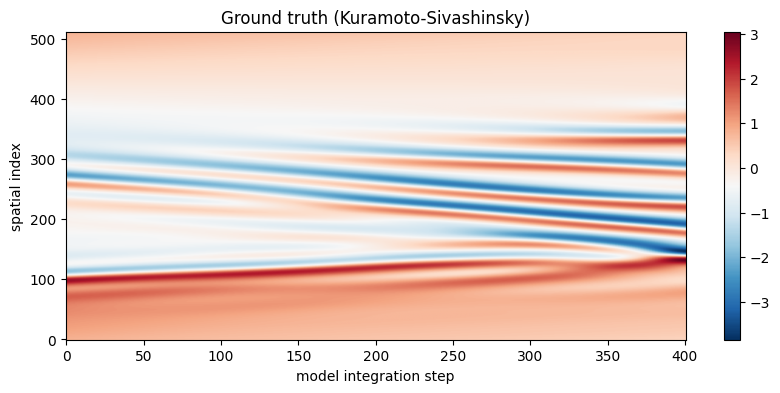

In [7]:
# Hovmoller diagram of the ground truth (state 0).
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(
    np.asarray(true_sol[0, :, 0, :]).T,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
)
ax.set_xlabel("model integration step")
ax.set_ylabel("spatial index")
ax.set_title("Ground truth (Kuramoto-Sivashinsky)")
fig.colorbar(im, ax=ax)
plt.show()

## 6. Initial ensemble

The initial ensemble represents our uncertain prior knowledge of the state. The configured `InitialEnsembleGenerator` centers `ensemble_size` members on a best guess (the truth's initial state, since `use_best_guess=True`) and perturbs them with noise scaled by the natural variability of the field.

We plot a handful of members against the truth to see the initial spread.

In [8]:
initial_ensemble_generator = instantiate(
    initial_ensemble_cfg, forward_model=forward_model
)
initial_ensemble = initial_ensemble_generator.sample(
    rng_key=initial_ensemble_key,
    ensemble_size=cfg.ensemble_size,
    best_guess=true_initial_state if initial_ensemble_cfg.use_best_guess else None,
)
logger.info(f"Initial ensemble generator: {initial_ensemble_generator}")
print("initial_ensemble shape [ensemble, num_states, state_dim]:", initial_ensemble.shape)

INFO:kuramoto_notebook:Initial ensemble generator: <non_gaussian_data_assim.ensemble_generation.initial_ensemble.InitialEnsembleGenerator object at 0x7f6aed59fb60>


initial_ensemble shape [ensemble, num_states, state_dim]: (50, 1, 512)


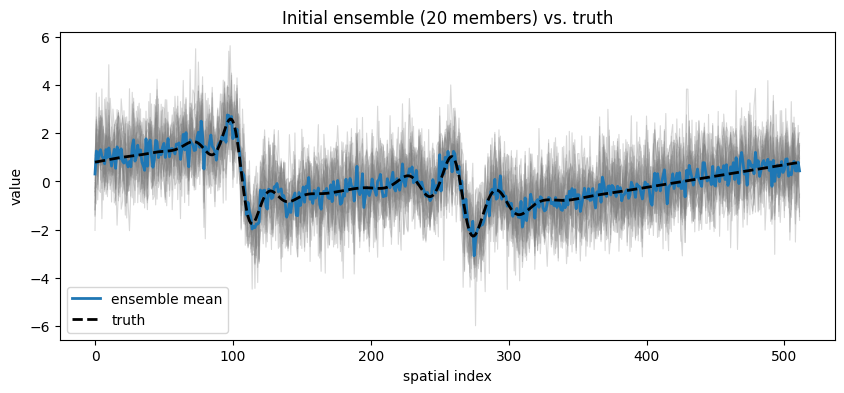

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for member in np.asarray(initial_ensemble[:20, 0, :]):
    ax.plot(member, color="gray", alpha=0.3, lw=0.8)
ax.plot(np.asarray(initial_ensemble[:, 0, :]).mean(0), color="C0", lw=2, label="ensemble mean")
ax.plot(np.asarray(true_initial_state[0, 0, :]), color="k", lw=2, ls="--", label="truth")
ax.set_xlabel("spatial index")
ax.set_ylabel("value")
ax.set_title("Initial ensemble (20 members) vs. truth")
ax.legend()
plt.show()

## 7. Observation operator and synthetic observations

The observation operator maps the full state to the observed quantities. For Kuramoto it is a `LinearObservationOperator` sampling every 4th grid point. The observation-error covariance `R` is diagonal with variance `cfg.case.obs_noise_variance`.

`generate_observations` then observes the **truth** at each assimilation step and adds Gaussian noise drawn with covariance `R`, producing the data the filter will assimilate.

In [10]:
obs_operator = instantiate(obs_operator_cfg)
R = jnp.eye(obs_operator.num_obs) * cfg.case.obs_noise_variance
logger.info(f"Observation operator: {obs_operator}")

observations = generate_observations(
    rng_key=obs_key,
    true_sol=true_sol,
    obs_operator=obs_operator,
    R=R,
    data_assimilation_steps=cfg.data_assimilation_steps,
    model_integration_steps=cfg.model_integration_steps,
)
print("num_obs:", obs_operator.num_obs)
print("observations shape [da_steps, num_obs]:", observations.shape)

INFO:kuramoto_notebook:Observation operator: <non_gaussian_data_assim.observations.observation_operator.LinearObservationOperator object at 0x7f6aed59fcb0>


num_obs: 128
observations shape [da_steps, num_obs]: (40, 128)


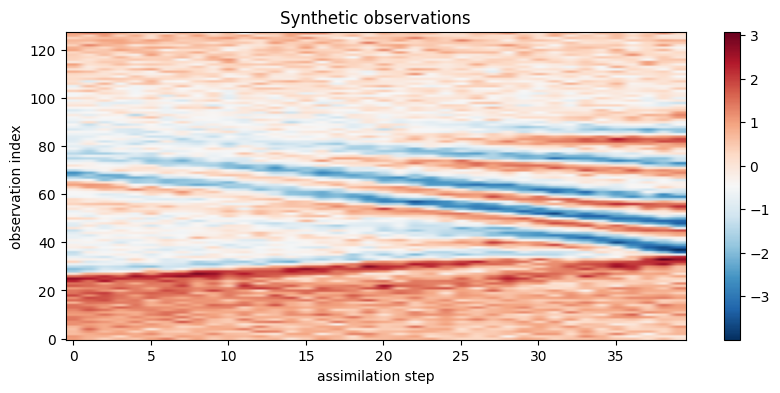

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(np.asarray(observations).T, aspect="auto", origin="lower", cmap="RdBu_r")
ax.set_xlabel("assimilation step")
ax.set_ylabel("observation index")
ax.set_title("Synthetic observations")
fig.colorbar(im, ax=ax)
plt.show()

## 8. Data-assimilation model

We instantiate the DA method (the EnKF) from the merged `da_method_cfg`, injecting the runtime objects it needs: ensemble size, observation-error covariance `R`, the observation operator, and the forward operator.

In [12]:
da_model = instantiate(
    da_method_cfg,
    ensemble_size=cfg.ensemble_size,
    R=R,
    obs_operator=obs_operator,
    forward_operator=forward_model,
)
logger.info(f"DA model: {da_model}")
da_model

INFO:kuramoto_notebook:DA model: <non_gaussian_data_assim.da_methods.enkf.EnsembleKalmanFilter object at 0x7f6aec1d0830>


## 9. Prepare ensembles and a reference (no-DA) forecast

We initialize the running `posterior_ensemble` and `prior_ensemble_da` containers with a time axis. We also roll the initial ensemble forward **without** any assimilation - this "reference" forecast is the baseline we compare the assimilated posterior against, to show how much the observations help.

In [13]:
posterior_ensemble = initial_ensemble.copy().reshape(
    cfg.ensemble_size, 1, cfg.case.num_states, cfg.case.state_dim
)
prior_ensemble_da = initial_ensemble.copy().reshape(
    cfg.ensemble_size, 1, cfg.case.num_states, cfg.case.state_dim
)

reference_ensemble = forward_model.rollout(
    initial_ensemble,
    cfg.data_assimilation_steps,
    return_model_integration_steps=True,
)
print("reference_ensemble shape:", reference_ensemble.shape)

reference_ensemble shape: (50, 401, 1, 512)


## 10. The data-assimilation loop

At each step we:

1. take the latest posterior as the current prior,
2. call the DA model - which **forecasts** the prior forward and then **analyzes** it against the current observation,
3. record the prior in observation space (used later for innovation diagnostics),
4. append the prior and posterior trajectories.

In [14]:
predicted_obs = []
logger.info(f"Running DA loop for {cfg.data_assimilation_steps} steps")
for i in tqdm(range(cfg.data_assimilation_steps)):
    rng_key, key = jax.random.split(rng_key)

    prior_current = posterior_ensemble[:, -1]

    posterior_next = da_model(
        prior_ensemble=prior_current,
        obs_vect=observations[i],
        rng_key=key,
        return_model_integration_steps=True,
    )
    if jnp.isnan(posterior_next).any():
        print(f"NaN in posterior_next at time {i}")
        break

    # Track prior ensemble in observation space.
    HXf = da_model.obs_operator(prior_current)  # (EnsSize, N_obs)
    predicted_obs.append(HXf)

    prior_ensemble_da = jnp.concatenate(
        [prior_ensemble_da, prior_current[:, None, :, :]], axis=1
    )
    posterior_ensemble = jnp.concatenate(
        [posterior_ensemble, posterior_next], axis=1
    )

logger.info("Finished DA loop")
print("posterior_ensemble shape:", posterior_ensemble.shape)

INFO:kuramoto_notebook:Running DA loop for 40 steps
100%|██████████| 40/40 [01:04<00:00,  1.60s/it]
INFO:kuramoto_notebook:Finished DA loop


posterior_ensemble shape: (50, 401, 1, 512)


## 11. Metrics

We compute standard skill metrics (RMSE, MAE, MAPE, CRPS) and their time-resolved variants, plus ensemble spread, for both the **reference** (no-DA) forecast and the **posterior** (assimilated) ensemble. The table makes the improvement from assimilation explicit.

In [15]:
rmse = RMSE(ensemble_aggregation="mean", time_aggregation="mean")
mae = MAE(ensemble_aggregation="mean", time_aggregation="mean")
mape = MAPE(ensemble_aggregation="mean", time_aggregation="mean")
crps = CRPS(time_aggregation="mean")
rmse_time = RMSE(ensemble_aggregation="mean", time_aggregation="none")
crps_time = CRPS(time_aggregation="none")
innov_white = NormalizedInnovations()
chi2_mean = ChiSquared(time_aggregation="mean")
chi2_time = ChiSquared(time_aggregation="none")


def get_metric_dict(ensemble, true_sol, state_dim: Optional[int] = None) -> dict:
    return {
        "rmse": rmse(ensemble, true_sol),
        "mae": mae(ensemble, true_sol),
        "mape": mape(ensemble, true_sol),
        "crps": crps(ensemble, true_sol),
        "rmse_time": rmse_time(ensemble, true_sol),
        "spread_time": ensemble_spread(ensemble, state_dim=state_dim),
        "crps_time": crps_time(ensemble, true_sol),
    }


reference_metrics = get_metric_dict(reference_ensemble, true_sol[0])
posterior_metrics = get_metric_dict(posterior_ensemble, true_sol[0])

post_metric_states = []
if cfg.case.num_states > 1:
    for i in range(cfg.case.num_states):
        post_metric_states.append(
            get_metric_dict(posterior_ensemble[:, :, i, :], true_sol[0, :, i, :])
        )

print_metrics_table(
    reference_metrics, posterior_metrics, title=f"{cfg.case.title} Metrics"
)


Kuramoto-Sivashinsky Metrics
--------------------------------------------
Metric     |      Reference |      Posterior
--------------------------------------------
RMSE       |       1.002781 |       0.096213
MAE        |       0.783582 |       0.074565
MAPE       |       7.816899 |       0.908318
CRPS       |       0.307394 |       0.037205
--------------------------------------------


## 12. Field plots: truth vs. reference vs. posterior

The project's `plot_high_dim_field` plotter (configured under `cfg.case.plotter`) draws Hovmoller diagrams and assimilation time-series, comparing the ground truth, the no-DA reference forecast, and the assimilated posterior side by side.

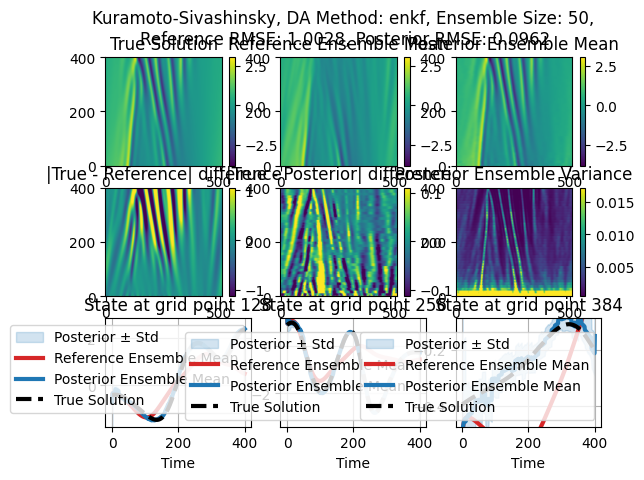

In [16]:
plotter = instantiate(plotter_cfg)
plotter(
    true_sol=true_sol,
    reference_ensemble=reference_ensemble,
    posterior_ensemble=posterior_ensemble,
    title=cfg.case.title,
    da_method_name=cfg.da_method.name,
    ensemble_size=cfg.ensemble_size,
    reference_metrics=reference_metrics,
    posterior_metrics=posterior_metrics,
    state_dim=cfg.case.state_dim,
    data_assimilation_steps=cfg.data_assimilation_steps,
    model_integration_steps=cfg.model_integration_steps,
)

## 13. Error time-series

`plot_metric_timeseries` shows how the posterior RMSE, spread, and CRPS evolve over the assimilation window.

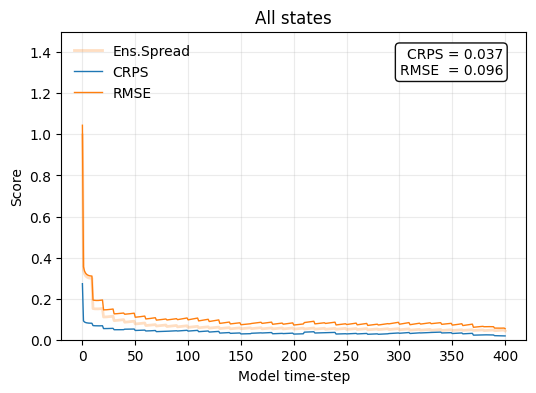

In [17]:
post_metrics_all = [posterior_metrics] + post_metric_states
_ = plot_metric_timeseries(post_metrics_all)

## 14. Innovation statistics (EnKF only)

For the EnKF we can check filter consistency via innovation diagnostics: the reduced chi-square (should be ~1 when the filter is well-calibrated) and the normalized innovations (should look like standard-normal white noise). We split the predicted observations per state and feed them to `plot_innov`.

INFO:matplotlib.mathtext:Substituting symbol N from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol N from STIXNonUnicode


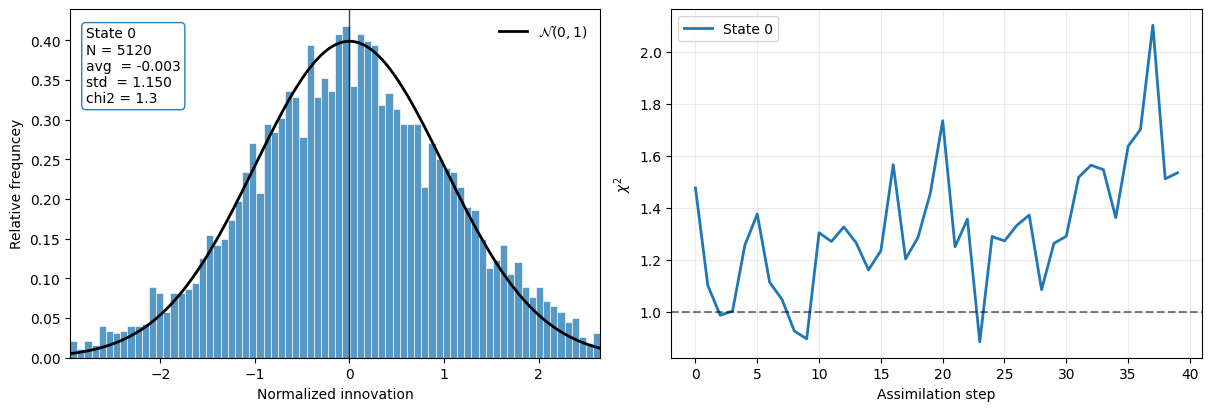

In [18]:
if cfg.da_method["name"] == "enkf":
    pred_obs = jnp.stack(predicted_obs, axis=0)  # [EnsSize, Assim-Step, N_obs]

    idx = 0
    predobs_states, obs_states, R_states = [], [], []
    for obs_state in da_model.obs_operator.obs_indices_per_state:
        i = obs_state.shape[0]
        predobs_states.append(pred_obs[:, :, idx : idx + i])
        obs_states.append(observations[:, idx : idx + i])
        R_states.append(R[idx : idx + i, idx : idx + i])
        idx += i

    innov_metric_list = []
    for p_obs, obs, R_state in zip(predobs_states, obs_states, R_states):
        innov_metric_list.append({
            "chi_sq_mean": chi2_mean(predicted_obs=p_obs, obs=obs, R=R_state),
            "chi_sq_time": chi2_time(predicted_obs=p_obs, obs=obs, R=R_state),
            "z": innov_white(predicted_obs=p_obs, obs=obs, R=R_state),
        })

    _ = plot_innov(
        innov_stats_list=innov_metric_list, bins=74, hist_range=None, show_fig=True
    )

## 15. Initial-condition diagnostics

Finally, `plot_initial_fields` visualizes the assimilated ensemble around the initial time against the truth and the best-guess profile.

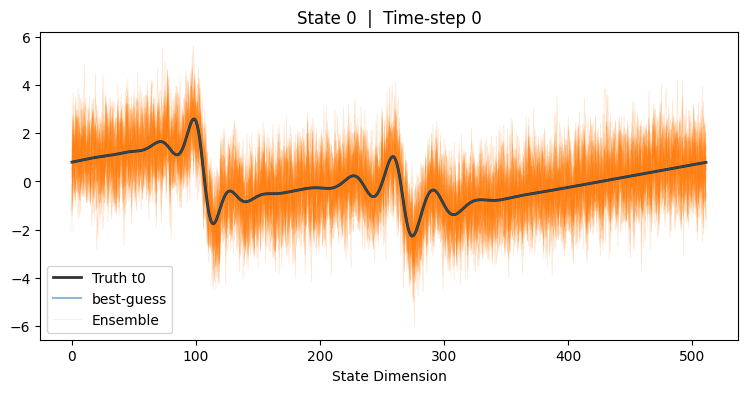

In [19]:
plot_initial_fields(
    ensemble=posterior_ensemble,
    truth_t0=true_sol,
    x_before_spinup=None,
    best_guess_profile=(
        true_initial_state[0] if initial_ensemble_cfg.use_best_guess else None
    ),
    bv_dict=None,
)